# Shape and columns

In [1]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent
raw_path = project_root / "data" / "raw" / "spy_1m.csv"

df = pd.read_csv(raw_path)
df.head(10)

,Datetime,Adj Close,Close,High,Low,Open,Volume
0,NaN,SPY,SPY,SPY,SPY,SPY,SPY
1,2025-12-29 14:30:00+00:00,688.0599975585938,688.0599975585938,688.0900268554688,687.1900024414062,687.5399780273438,2958189
2,2025-12-29 14:35:00+00:00,688.7899780273438,688.7899780273438,689.2000122070312,687.9199829101562,688.0499877929688,1459499
3,2025-12-29 14:40:00+00:00,688.4299926757812,688.4299926757812,688.7999877929688,688.22998046875,688.7999877929688,969638
4,2025-12-29 14:45:00+00:00,687.8599853515625,687.8599853515625,688.4400024414062,687.5700073242188,688.4400024414062,1301729
5,2025-12-29 14:50:00+00:00,687.7951049804688,687.7951049804688,688.25,687.4600219726562,687.8499755859375,913235
6,2025-12-29 14:55:00+00:00,687.5599975585938,687.5599975585938,687.9600219726562,687.3300170898438,687.7999877929688,667435
7,2025-12-29 15:00:00+00:00,687.3699951171875,687.3699951171875,687.8699951171875,687.2999267578125,687.5599975585938,523754
8,2025-12-29 15:05:00+00:00,687.0900268554688,687.0900268554688,687.5800170898438,687.0599975585938,687.3599853515625,857293
9,2025-12-29 15:10:00+00:00,687.0996704101562,687.0996704101562,687.219970703125,686.8200073242188,687.0900268554688,839757


# Convert datetime and remove junk row

In [8]:
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
df = df[df["Datetime"].notna()].copy()
df.head()

,Datetime,Adj Close,Close,High,Low,Open,Volume
1,2025-12-29 14:30:00+00:00,688.0599975585938,688.0599975585938,688.0900268554688,687.1900024414062,687.5399780273438,2958189
2,2025-12-29 14:35:00+00:00,688.7899780273438,688.7899780273438,689.2000122070312,687.9199829101562,688.0499877929688,1459499
3,2025-12-29 14:40:00+00:00,688.4299926757812,688.4299926757812,688.7999877929688,688.22998046875,688.7999877929688,969638
4,2025-12-29 14:45:00+00:00,687.8599853515625,687.8599853515625,688.4400024414062,687.5700073242188,688.4400024414062,1301729
5,2025-12-29 14:50:00+00:00,687.7951049804688,687.7951049804688,688.25,687.4600219726562,687.8499755859375,913235


# Check dtypes

In [9]:
df.dtypes

Datetime     datetime64[us, UTC]
Adj Close                    str
Close                        str
High                         str
Low                          str
Open                         str
Volume                       str
dtype: object

# Convert numeric columns

In [21]:
numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes

Datetime     datetime64[us, UTC]
Adj Close                float64
Close                    float64
High                     float64
Low                      float64
Open                     float64
Volume                     int64
hour                       int32
minute                     int32
date                      object
dtype: object

# Check missing values

In [22]:
df.isna().sum()

Datetime     0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
hour         0
minute       0
date         0
dtype: int64

# Inspect time coverage

In [23]:
df["Datetime"].min(), df["Datetime"].max()

(Timestamp('2025-12-29 14:30:00+0000', tz='UTC'),
 Timestamp('2026-03-25 19:55:00+0000', tz='UTC'))

# Check hours

In [24]:
df["hour"] = df["Datetime"].dt.hour
df["minute"] = df["Datetime"].dt.minute
df[["Datetime", "hour", "minute"]].head(20)

,Datetime,hour,minute
1,2025-12-29 14:30:00+00:00,14,30
2,2025-12-29 14:35:00+00:00,14,35
3,2025-12-29 14:40:00+00:00,14,40
4,2025-12-29 14:45:00+00:00,14,45
5,2025-12-29 14:50:00+00:00,14,50
6,2025-12-29 14:55:00+00:00,14,55
7,2025-12-29 15:00:00+00:00,15,0
8,2025-12-29 15:05:00+00:00,15,5
9,2025-12-29 15:10:00+00:00,15,10
10,2025-12-29 15:15:00+00:00,15,15


# Bars per day

In [25]:
df["date"] = df["Datetime"].dt.date
bars_per_day = df.groupby("date").size()
bars_per_day.describe(), bars_per_day.head()

(count    60.0
 mean     78.0
 std       0.0
 min      78.0
 25%      78.0
 50%      78.0
 75%      78.0
 max      78.0
 dtype: float64,
 date
 2025-12-29    78
 2025-12-30    78
 2025-12-31    78
 2026-01-02    78
 2026-01-05    78
 dtype: int64)

# Quick plot

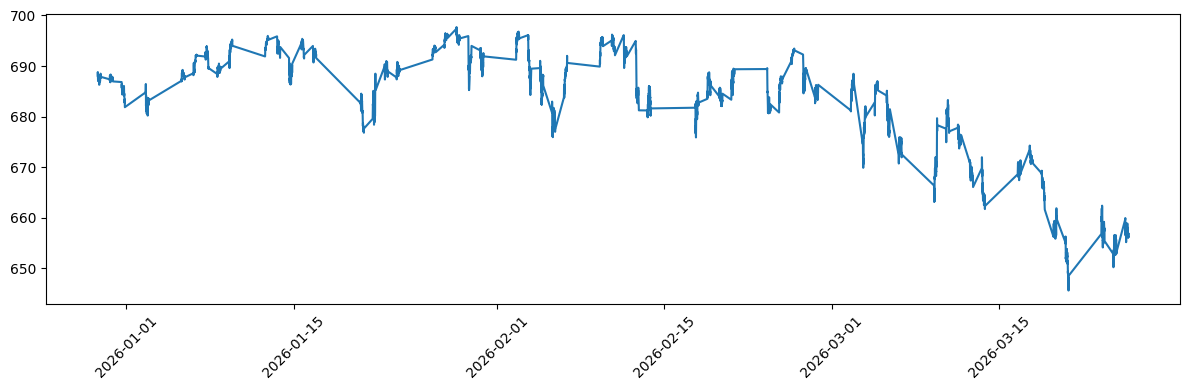

In [26]:
import matplotlib.pyplot as plt

df = df.sort_values("Datetime")
plt.figure(figsize=(12, 4))
plt.plot(df["Datetime"], df["Close"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\999ch\Documents\Quant Projects\teza-move-classification\.venv\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


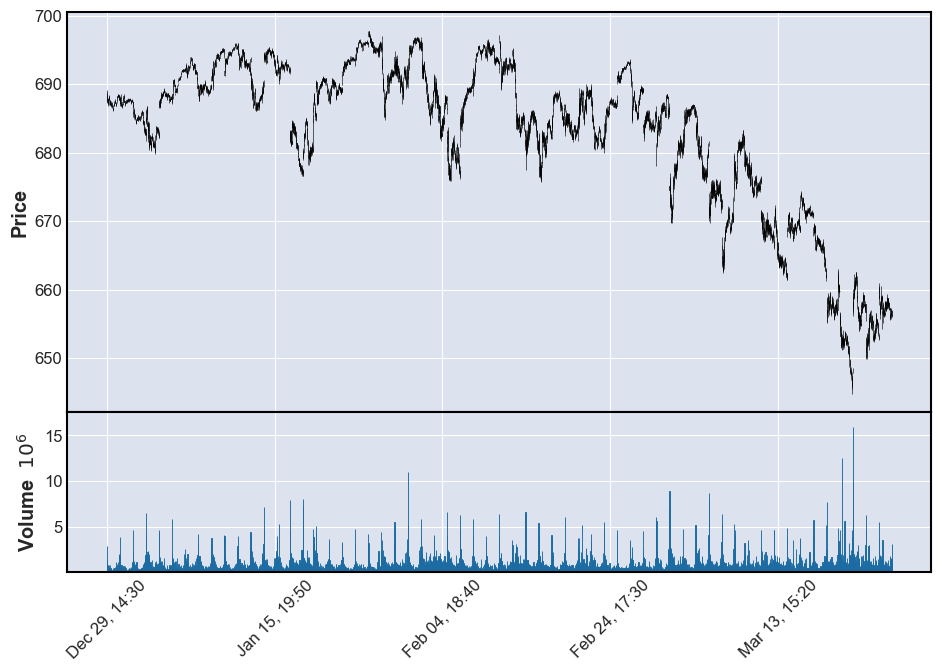

In [28]:
import mplfinance as mpf

plot_df = df.copy()
plot_df = plot_df.sort_values("Datetime")
plot_df = plot_df.set_index("Datetime")

mpf.plot(
    plot_df,
    type="candle",
    volume=True,
    figsize=(12, 8)
)